# 04 — Decode & durations

GMM has no decode step (`predict` is pointwise). HMM look-ahead is in Viterbi/smoothed only; filtered decode is causal.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path.cwd().parent))
from regime_utils import *

std_variants = {
    "full": load_full_sample_std(),
    "rolling": load_rolling_std(),
    "expanding": load_expanding_std(),
}

rows = []
labels_by_cell = {}
for std_name, df in std_variants.items():
    X = df.values
    gmm = fit_gmm(X)
    hmm = fit_hmm(X)
    gmm_l = gmm.predict(X)
    vit = viterbi_decode(hmm, X)
    sm = smoothed_decode(hmm, X)
    filt = filtered_decode(hmm, X)
    for method, labels in [
        ("GMM pointwise", gmm_l),
        ("HMM Viterbi", vit),
        ("HMM smoothed", sm),
        ("HMM filtered", filt),
    ]:
        rows.append({
            "Std variant": std_name,
            "Method": method,
            "Mean duration (weeks)": round(run_length_mean(labels), 1),
        })
        labels_by_cell[(std_name, method)] = labels

duration_table = pd.DataFrame(rows)
print(duration_table.to_string(index=False))
commit_table(duration_table.pivot(index="Std variant", columns="Method", values="Mean duration (weeks)"),
             "04_duration_table")


Std variant        Method  Mean duration (weeks)
       full GMM pointwise                    9.0
       full   HMM Viterbi                   55.9
       full  HMM smoothed                   55.9
       full  HMM filtered                   41.2
    rolling GMM pointwise                    6.2
    rolling   HMM Viterbi                   18.9
    rolling  HMM smoothed                   17.2
    rolling  HMM filtered                   13.5
  expanding GMM pointwise                    7.3
  expanding   HMM Viterbi                   50.4
  expanding  HMM smoothed                   50.4
  expanding  HMM filtered                   37.8
04_duration_table: matches committed


### Bootstrap CIs on mean duration

The sampling unit for a run-length mean is the **spell**, not the week — so bootstrap spells, not the label sequence. A block bootstrap on the raw sequence would artificially fragment runs and bias durations downward, which is exactly the look-ahead-style artifact this notebook is about, so it's the wrong tool here even though it's the more common default. 95% CIs are the 2.5th/97.5th percentiles of 10,000 resampled spell-duration means.

For the two full-sample headline ratios (HMM Viterbi/GMM and HMM filtered/GMM), CIs come from dividing the two models' bootstrap draws elementwise — an independence approximation, since GMM and HMM are fit to the same underlying sample rather than resampled jointly. Full-sample HMM Viterbi has only ~31 spells (1,564 weeks / 55.9 mean duration), so its CI is wide by construction; that width is the honest result, not something to paper over.

In [2]:
def bootstrap_mean_duration(labels, n_boot=10_000, seed=0):
    """Bootstrap the mean spell duration by resampling spells (not weeks)."""
    d = regime_durations(labels)
    rng = np.random.default_rng(seed)
    return d[rng.integers(0, d.size, size=(n_boot, d.size))].mean(axis=1)

ci_rows = []
draws_by_cell = {}
for (std_name, method), labels in labels_by_cell.items():
    draws = bootstrap_mean_duration(labels)
    draws_by_cell[(std_name, method)] = draws
    lo, hi = np.percentile(draws, [2.5, 97.5])
    n_spells = regime_durations(labels).size
    ci_rows.append({
        "Std variant": std_name,
        "Method": method,
        "Mean duration (weeks)": round(run_length_mean(labels), 1),
        "n spells": n_spells,
        "CI lo": lo,
        "CI hi": hi,
        "95% CI": f"[{lo:.1f}, {hi:.1f}]",
    })

ci_table = pd.DataFrame(ci_rows)
print(ci_table.drop(columns=["CI lo", "CI hi"]).to_string(index=False))

ci_numeric = ci_table.assign(cell=ci_table["Std variant"] + " / " + ci_table["Method"]).set_index("cell")
commit_table(ci_numeric[["Mean duration (weeks)", "n spells", "CI lo", "CI hi"]], "04_duration_bootstrap_ci",
             atol=1e-2)  # bootstrap draws are seeded but percentiles can shift in the last digit across numpy versions


Std variant        Method  Mean duration (weeks)  n spells       95% CI
       full GMM pointwise                    9.0       174  [6.6, 11.6]
       full   HMM Viterbi                   55.9        28 [35.2, 80.4]
       full  HMM smoothed                   55.9        28 [35.2, 80.4]
       full  HMM filtered                   41.2        38 [24.7, 60.2]
    rolling GMM pointwise                    6.2       245   [5.2, 7.2]
    rolling   HMM Viterbi                   18.9        80 [14.9, 23.4]
    rolling  HMM smoothed                   17.2        88 [14.1, 20.6]
    rolling  HMM filtered                   13.5       112 [11.2, 16.1]
  expanding GMM pointwise                    7.3       208   [5.5, 9.3]
  expanding   HMM Viterbi                   50.4        30 [31.3, 73.8]
  expanding  HMM smoothed                   50.4        30 [31.3, 73.7]
  expanding  HMM filtered                   37.8        40 [22.9, 56.8]
04_duration_bootstrap_ci: matches committed


In [3]:
# Headline persistence ratios (full-sample std): HMM / GMM duration, as an interval, not a point estimate
gmm_draws = draws_by_cell[("full", "GMM pointwise")]
ratio_rows = []
for hmm_method in ["HMM Viterbi", "HMM filtered"]:
    hmm_draws = draws_by_cell[("full", hmm_method)]
    ratio_draws = hmm_draws / gmm_draws  # independence approximation — see markdown above
    lo, hi = np.percentile(ratio_draws, [2.5, 97.5])
    point = run_length_mean(labels_by_cell[("full", hmm_method)]) / run_length_mean(labels_by_cell[("full", "GMM pointwise")])
    print(f"{hmm_method} / GMM pointwise duration ratio: {point:.1f}x, 95% CI [{lo:.1f}x, {hi:.1f}x]")
    ratio_rows.append({"HMM method": hmm_method, "ratio": point, "CI lo": lo, "CI hi": hi})

commit_table(pd.DataFrame(ratio_rows).set_index("HMM method"), "04_headline_duration_ratios", atol=1e-2)


HMM Viterbi / GMM pointwise duration ratio: 6.2x, 95% CI [3.7x, 9.9x]
HMM filtered / GMM pointwise duration ratio: 4.6x, 95% CI [2.6x, 7.6x]
04_headline_duration_ratios: matches committed


In [4]:

# Transition entropy (full-sample std, named states — integer IDs permute across fits)
df_full = std_variants["full"]
X = df_full.values
gmm = fit_gmm(X)
hmm = fit_hmm(X)
vix = load_raw_features().loc[df_full.index, "VIX"]
entropy_cols = {}
for name, ints in [
    ("GMM", gmm.predict(X)),
    ("HMM Viterbi", viterbi_decode(hmm, X)),
    ("HMM filtered", filtered_decode(hmm, X)),
]:
    named = apply_label_map(ints, label_map_from_mean_vix(ints, vix))
    ent = transition_entropy(named).reindex([CALM_LABEL, TRANSITIONAL_LABEL, STRESS_LABEL])
    print(f"{name} transition entropy (bits):\n", ent.round(3))
    entropy_cols[name] = ent

entropy_table = pd.DataFrame(entropy_cols)
entropy_table.loc["Average"] = entropy_table.mean()
commit_table(entropy_table, "04_transition_entropy")


GMM transition entropy (bits):
 Calm            0.524
Transitional    0.618
Stressful       0.643
dtype: float64
HMM Viterbi transition entropy (bits):
 Calm            0.10
Transitional    0.13
Stressful       0.18
dtype: float64
HMM filtered transition entropy (bits):
 Calm            0.155
Transitional    0.141
Stressful       0.233
dtype: float64
04_transition_entropy: matches committed


In [5]:

# Cross-model ARI on integer labels (no remapping)
gmm_l = gmm.predict(X)
ari_cols = {}
for decode_name, hmm_l in [("Viterbi", viterbi_decode(hmm, X)), ("filtered", filtered_decode(hmm, X))]:
    ari = cross_model_ari(gmm_l, hmm_l)
    print(f"ARI GMM vs HMM {decode_name}: {ari:.3f}")
    ari_cols[f"GMM vs HMM {decode_name}"] = ari

# Raw agreement needs named labels (integer IDs aren't comparable across models)
vit = viterbi_decode(hmm, X)
gmm_named = apply_label_map(gmm_l, label_map_from_mean_vix(gmm_l, vix))
vit_named = apply_label_map(vit, label_map_from_mean_vix(vit, vix))
raw_agreement = (gmm_named.values == vit_named.values).mean()
print(f"\nRaw label agreement (GMM vs HMM Viterbi, named): {raw_agreement:.1%}")

pre_2005 = df_full.index < "2005-01-01"
ari_pre = cross_model_ari(gmm_l[pre_2005], vit[pre_2005])
ari_post = cross_model_ari(gmm_l[~pre_2005], vit[~pre_2005])
print(f"\nSubsample ARI (GMM vs HMM Viterbi, integer labels):")
print(f"  Pre-2005:  {ari_pre:.3f}")
print(f"  Post-2005: {ari_post:.3f}")

print("\nGMM ~9 wk duration is honest (no L2 decode). HMM Viterbi full-sample duration is inflated by global smoothing "
      "(see duration table above).")

commit_table(pd.DataFrame({"value": {**ari_cols, "Raw label agreement (named)": raw_agreement,
                                      "Pre-2005 ARI": ari_pre, "Post-2005 ARI": ari_post}}),
             "04_cross_model_agreement")


ARI GMM vs HMM Viterbi: 0.348
ARI GMM vs HMM filtered: 0.332

Raw label agreement (GMM vs HMM Viterbi, named): 35.7%

Subsample ARI (GMM vs HMM Viterbi, integer labels):
  Pre-2005:  0.551
  Post-2005: 0.260

GMM ~9 wk duration is honest (no L2 decode). HMM Viterbi full-sample duration is inflated by global smoothing (see duration table above).
04_cross_model_agreement: matches committed


### GMM vs HMM agreement heatmap

3×3 co-classification on **named** labels (full-sample std, HMM Viterbi). Counts drive color; cell annotations show **weeks** and **row %** (share of each GMM regime). GMM Calm and Stressful weeks land mostly on the diagonal (49% and 41% co-labeled the same by HMM), but most GMM Transitional weeks (87%) are co-labeled HMM Stressful — HMM's broader Stressful regime (33.2% share vs. GMM's 13.0%) absorbs the bulk of what GMM calls Transitional.

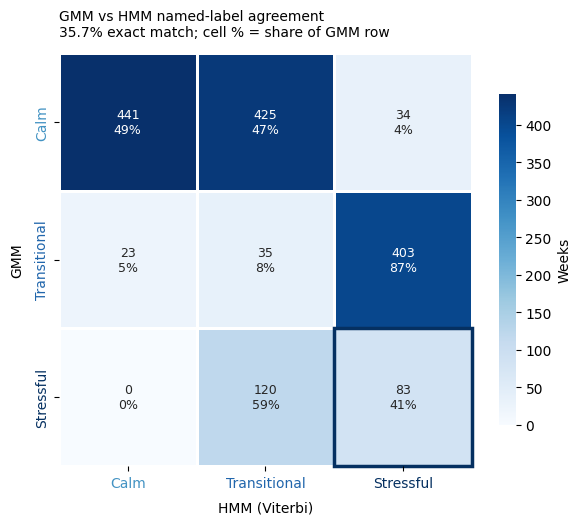

Regime_label  Calm  Transitional  Stressful
Regime_label                               
Calm           441           425         34
Transitional    23            35        403
Stressful        0           120         83

Stress–Stress: 83 wk (41% of GMM Stressful weeks)
04_gmm_hmm_crosstab_counts: matches committed


In [6]:
import seaborn as sns

REGIME_COLORS = {
    CALM_LABEL: "#4393c3",
    TRANSITIONAL_LABEL: "#2166ac",
    STRESS_LABEL: "#053061",
}
LABEL_ORDER = [CALM_LABEL, TRANSITIONAL_LABEL, STRESS_LABEL]
FONT = {"fontsize": 10, "fontweight": "normal"}

raw = load_raw_features().loc[df_full.index]
gmm_named = build_regime_frame(raw, gmm_l, "Regime_GMM")["Regime_label"]
hmm_named = build_regime_frame(raw, viterbi_decode(hmm, X), "Regime_HMM")["Regime_label"]

counts = pd.crosstab(gmm_named, hmm_named).reindex(
    index=LABEL_ORDER, columns=LABEL_ORDER, fill_value=0
)
row_pct = counts.div(counts.sum(axis=1), axis=0) * 100
exact_agree = (gmm_named.values == hmm_named.values).mean()

annot = np.empty((3, 3), dtype=object)
for i, g in enumerate(LABEL_ORDER):
    for j, h in enumerate(LABEL_ORDER):
        annot[i, j] = f"{int(counts.iloc[i, j])}\n{row_pct.iloc[i, j]:.0f}%"

fig, ax = plt.subplots(figsize=(6.2, 5.2))
sns.heatmap(
    counts,
    annot=annot,
    fmt="",
    cmap="Blues",
    annot_kws={"size": 9, "weight": "normal"},
    cbar_kws={"label": "Weeks", "shrink": 0.8},
    linewidths=2,
    linecolor="white",
    ax=ax,
    square=True,
    vmin=0,
)
ax.add_patch(
    plt.Rectangle(
        (2, 2),
        1,
        1,
        fill=False,
        edgecolor=REGIME_COLORS[STRESS_LABEL],
        linewidth=2.5,
        clip_on=False,
    )
)
for tick, label in zip(ax.get_xticklabels(), LABEL_ORDER):
    tick.set_color(REGIME_COLORS[label])
    tick.set_fontsize(10)
    tick.set_fontweight("normal")
for tick, label in zip(ax.get_yticklabels(), LABEL_ORDER):
    tick.set_color(REGIME_COLORS[label])
    tick.set_fontsize(10)
    tick.set_fontweight("normal")

ax.set_xlabel("HMM (Viterbi)", **FONT, labelpad=8)
ax.set_ylabel("GMM", **FONT, labelpad=8)
ax.set_title(
    "GMM vs HMM named-label agreement\n"
    f"{exact_agree:.1%} exact match; cell % = share of GMM row",
    **FONT,
    loc="left",
    pad=12,
)
plt.tight_layout()
plt.show()

print(counts.to_string())
print(f"\nStress–Stress: {counts.loc[STRESS_LABEL, STRESS_LABEL]} wk "
      f"({row_pct.loc[STRESS_LABEL, STRESS_LABEL]:.0f}% of GMM Stressful weeks)")

commit_table(counts.astype(float), "04_gmm_hmm_crosstab_counts")
